# BCS 404: Introduction to Data Science with Python
## Exploratory Data Analysis, Statistical Analysis and Machine Learning using the Titanic Dataset

**Institution:** Accra Technical University, Department of Computer Science
**Course:** BCS 404 — Introduction to Data Science with Python
**Lecturer:** Dr. Joseph Dadzie
**Academic Year:** 2025/2026, Second Semester

This notebook performs the full project workflow: data acquisition, cleaning, visualisation, statistical analysis, and a machine learning classification model that predicts passenger survival on the Titanic.

## Import Libraries
We import the core Python data-science stack required for this project.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, ConfusionMatrixDisplay

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (8, 5)
pd.set_option('display.max_columns', None)


## Task 1: Data Acquisition

The dataset used is the **Titanic: Machine Learning from Disaster** dataset (originally hosted on Kaggle: https://www.kaggle.com/competitions/titanic/data). It records demographic and travel information for 891 passengers aboard the RMS Titanic, along with whether each passenger survived the sinking.

The file `titanic.csv` used here is the same well-known training set distributed for the Kaggle Titanic competition. It was obtained as a CSV file and loaded directly with pandas.

In [2]:
df = pd.read_csv("data/titanic.csv")
print("Dataset dimensions (rows, columns):", df.shape)


Dataset dimensions (rows, columns): (891, 12)


In [3]:
print("Column names:")
list(df.columns)


Column names:


['PassengerId',
 'Survived',
 'Pclass',
 'Name',
 'Sex',
 'Age',
 'SibSp',
 'Parch',
 'Ticket',
 'Fare',
 'Cabin',
 'Embarked']

In [4]:
df.head()


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [5]:
df.dtypes


PassengerId      int64
Survived         int64
Pclass           int64
Name               str
Sex                str
Age            float64
SibSp            int64
Parch            int64
Ticket             str
Fare           float64
Cabin              str
Embarked           str
dtype: object

**Column dictionary**

| Column | Description |
|---|---|
| PassengerId | Unique identifier for each passenger |
| Survived | Survival indicator (0 = No, 1 = Yes) — the target variable |
| Pclass | Ticket / passenger class (1 = 1st, 2 = 2nd, 3 = 3rd) — a proxy for socio-economic status |
| Name | Passenger's full name |
| Sex | Passenger's sex |
| Age | Age in years |
| SibSp | Number of siblings/spouses aboard |
| Parch | Number of parents/children aboard |
| Ticket | Ticket number |
| Fare | Passenger fare |
| Cabin | Cabin number |
| Embarked | Port of embarkation (C = Cherbourg, Q = Queenstown, S = Southampton) |

The dataset has **891 rows and 12 columns**, mixing numerical (`Age`, `Fare`, `SibSp`, `Parch`), categorical (`Sex`, `Embarked`, `Pclass`), and identifier/text fields (`PassengerId`, `Name`, `Ticket`, `Cabin`).

## Task 2: Data Cleaning

### 2.1 Detect missing values

In [6]:
df.isnull().sum()


PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

**Observation:** `Age` has 177 missing values (~19.9%), `Cabin` has 687 missing values (~77.1%), and `Embarked` has 2 missing values.

### 2.2 Detect duplicated observations

In [7]:
print("Number of duplicated rows:", df.duplicated().sum())


Number of duplicated rows: 0


No duplicate rows were found in the raw dataset.

### 2.3 Handle missing values and clean the data

The preprocessing decisions made, with justification, are as follows:

1. **`Age` (177 missing, numeric):** Imputed with the **median** age rather than the mean, because `Age` is right-skewed (a few elderly passengers pull the mean upward) and the median is more robust to outliers, giving a more representative "typical" age.
2. **`Embarked` (2 missing, categorical):** Imputed with the **mode** (the most frequent port, "S" — Southampton), since only two values are missing and using the most common category introduces minimal bias.
3. **`Cabin` (687 missing, ~77%):** **Dropped entirely.** With over three-quarters of values missing, any imputation would be highly speculative and would not meaningfully inform the analysis; retaining it would also complicate later modelling steps.
4. **Duplicates:** None were found, so no rows were removed on this basis, but a `drop_duplicates()` step is retained for robustness/reproducibility.

These decisions balance data retention against the risk of introducing bias, and keep the pipeline reproducible.

In [8]:
df_clean = df.copy()

# Impute Age with the median (robust to skew/outliers)
df_clean['Age'] = df_clean['Age'].fillna(df_clean['Age'].median())

# Impute Embarked with the mode (only 2 missing values)
df_clean['Embarked'] = df_clean['Embarked'].fillna(df_clean['Embarked'].mode()[0])

# Drop Cabin: ~77% missing, not usable
df_clean.drop(columns=['Cabin'], inplace=True)

# Remove any duplicate rows (defensive step; none were found)
df_clean.drop_duplicates(inplace=True)

print("Missing values after cleaning:")
print(df_clean.isnull().sum())
print("\nCleaned dataset shape:", df_clean.shape)


Missing values after cleaning:
PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64

Cleaned dataset shape: (891, 11)


In [9]:
df_clean.head()


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,S


## Task 3: Data Visualisation

Six visualisations are produced below, each with a title, axis labels, and a brief interpretation.

### 3.1 Histogram of Passenger Ages

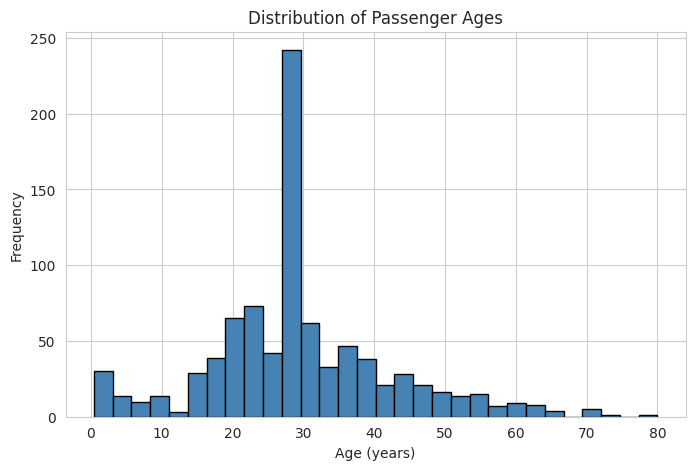

In [10]:
plt.figure(figsize=(8,5))
plt.hist(df_clean['Age'], bins=30, color='steelblue', edgecolor='black')
plt.title("Distribution of Passenger Ages")
plt.xlabel("Age (years)")
plt.ylabel("Frequency")
plt.savefig("figures/1_age_histogram.png", dpi=150, bbox_inches='tight')
plt.show()


**Interpretation:** The age distribution is right-skewed and concentrated between roughly 20 and 40 years, with a visible spike around age 28–29 caused by median imputation of the missing values. Very few passengers were older than 60, and there is a small secondary bump for infants/young children.

### 3.2 Bar Chart of Passenger Class Distribution

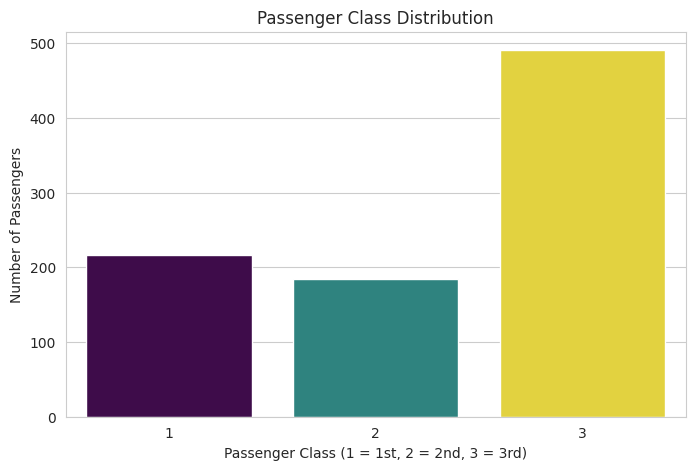

In [11]:
plt.figure(figsize=(8,5))
sns.countplot(x='Pclass', data=df_clean, hue='Pclass', palette='viridis', legend=False)
plt.title("Passenger Class Distribution")
plt.xlabel("Passenger Class (1 = 1st, 2 = 2nd, 3 = 3rd)")
plt.ylabel("Number of Passengers")
plt.savefig("figures/2_pclass_bar.png", dpi=150, bbox_inches='tight')
plt.show()


**Interpretation:** Third class passengers make up the largest group (about 55% of all passengers), more than first and second class combined. This reflects the Titanic's passenger composition, dominated by emigrants and lower-fare travellers.

### 3.3 Boxplot of Age by Passenger Class

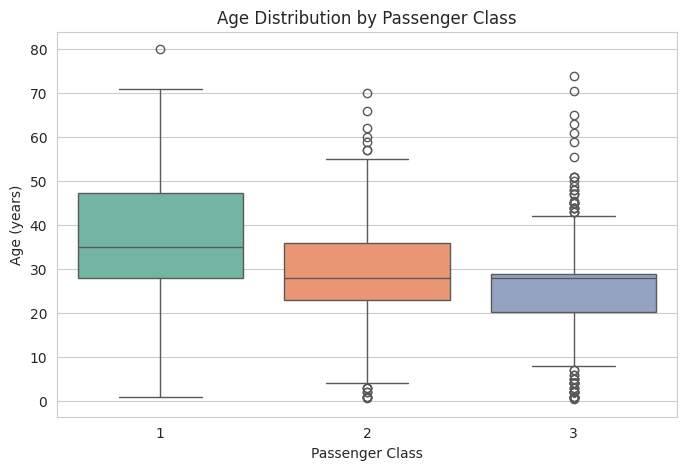

In [12]:
plt.figure(figsize=(8,5))
sns.boxplot(x='Pclass', y='Age', data=df_clean, hue='Pclass', palette='Set2', legend=False)
plt.title("Age Distribution by Passenger Class")
plt.xlabel("Passenger Class")
plt.ylabel("Age (years)")
plt.savefig("figures/3_age_by_pclass_box.png", dpi=150, bbox_inches='tight')
plt.show()


**Interpretation:** Median age decreases as class number increases: first-class passengers are typically older (median around the high 30s), while third-class passengers skew younger (median around late 20s and lower). First class also shows a wider age range and several older outliers.

### 3.4 Scatter Plot of Age versus Fare

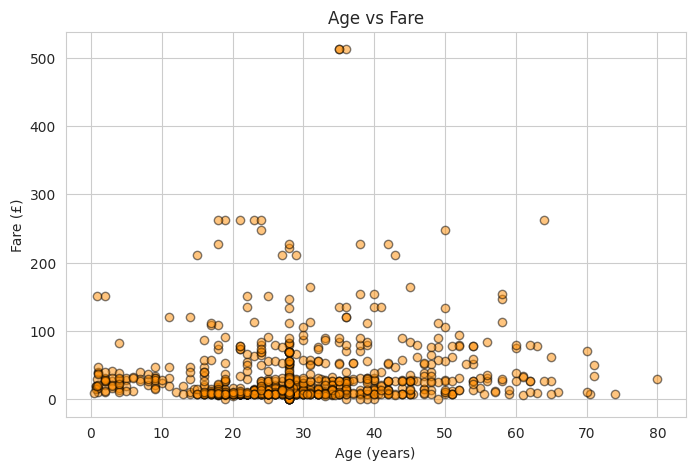

In [13]:
plt.figure(figsize=(8,5))
plt.scatter(df_clean['Age'], df_clean['Fare'], alpha=0.5, c='darkorange', edgecolor='k')
plt.title("Age vs Fare")
plt.xlabel("Age (years)")
plt.ylabel("Fare (£)")
plt.savefig("figures/4_age_vs_fare_scatter.png", dpi=150, bbox_inches='tight')
plt.show()


**Interpretation:** There is no strong linear relationship between age and fare — passengers of all ages paid low fares, but the handful of very high fares (above £200) were paid by passengers spread across a wide age range, suggesting fare is driven more by class and cabin/group size than by age itself.

### 3.5 Correlation Heatmap

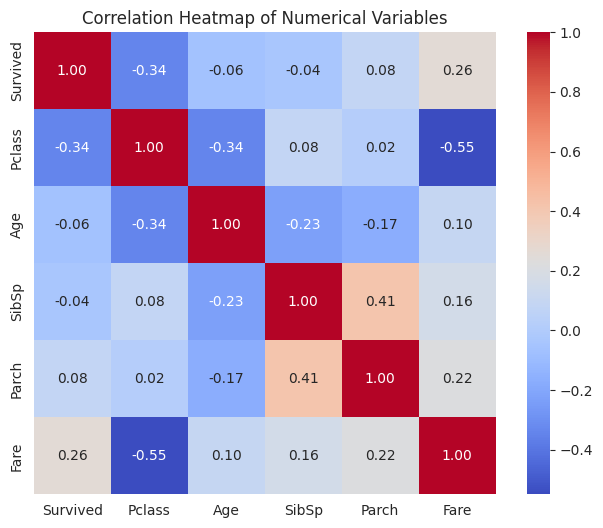

In [14]:
num_cols = ['Survived', 'Pclass', 'Age', 'SibSp', 'Parch', 'Fare']
corr = df_clean[num_cols].corr()

plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f', square=True)
plt.title("Correlation Heatmap of Numerical Variables")
plt.savefig("figures/5_correlation_heatmap.png", dpi=150, bbox_inches='tight')
plt.show()


**Interpretation:** `Pclass` and `Fare` show the strongest correlation of the set (-0.55): higher-numbered (lower) classes pay lower fares, as expected. `Survived` correlates negatively with `Pclass` (-0.34) and positively with `Fare` (0.26), hinting that wealthier, higher-class passengers were more likely to survive. `SibSp` and `Parch` are moderately positively correlated (0.41), since both relate to family size.

### 3.6 Pairplot of Selected Numerical Variables

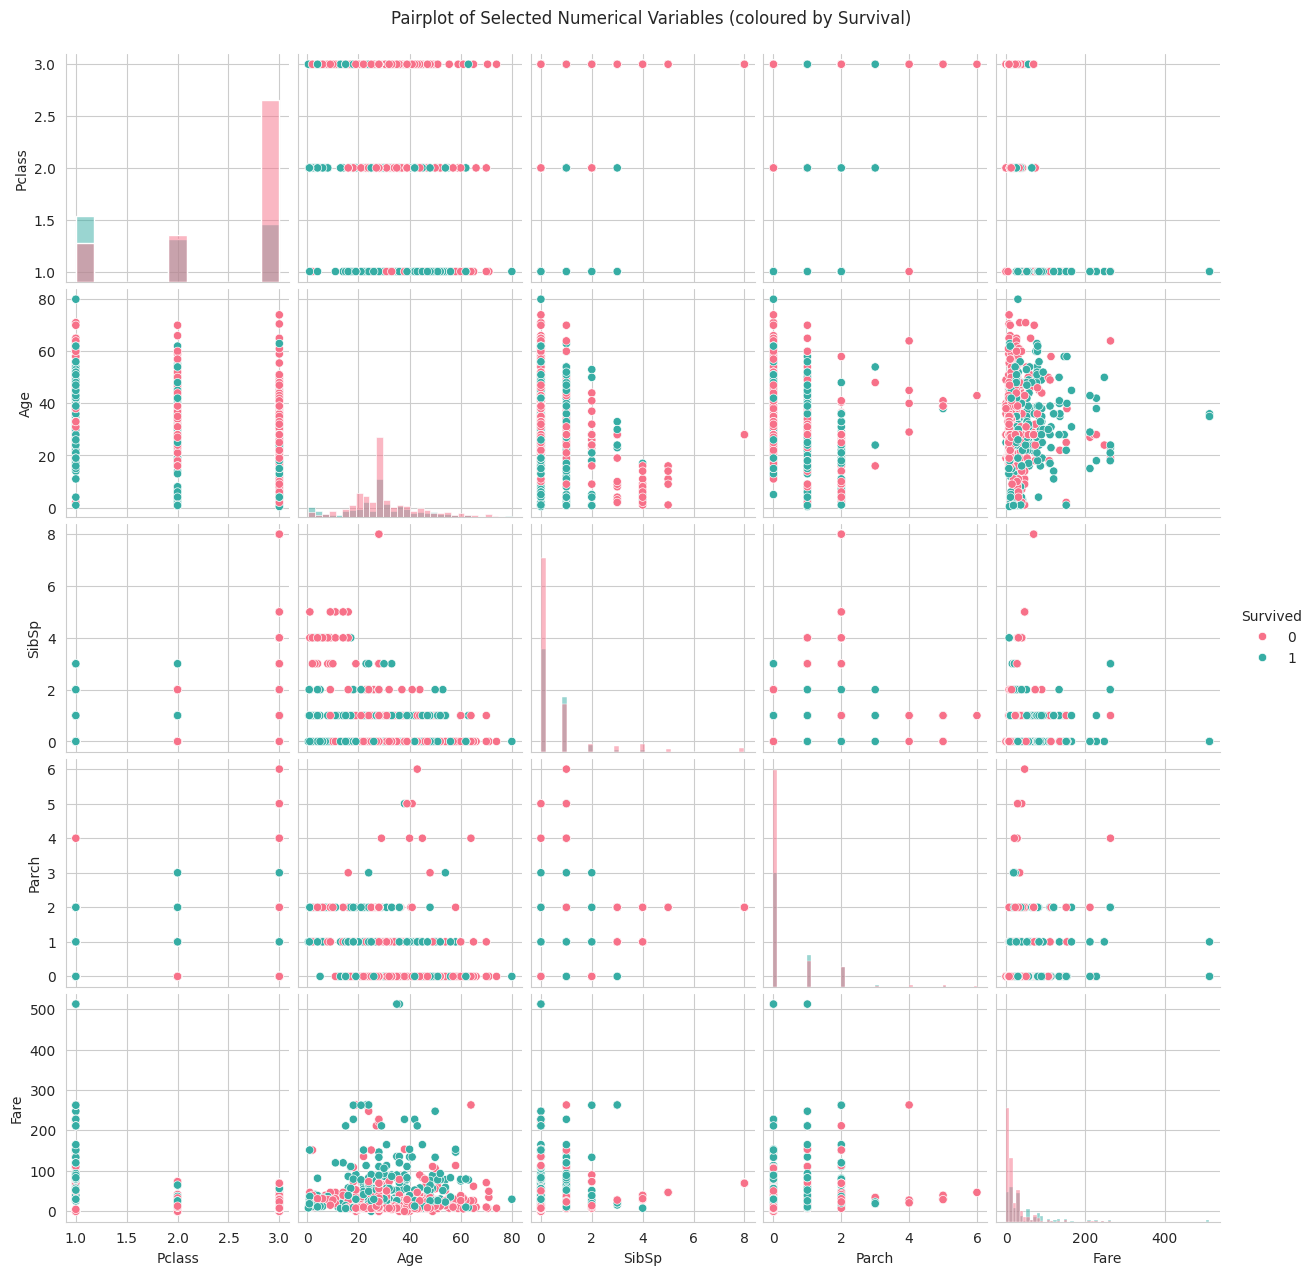

In [15]:
pp = sns.pairplot(df_clean[num_cols], hue='Survived', palette='husl', diag_kind='hist')
pp.fig.suptitle("Pairplot of Selected Numerical Variables (coloured by Survival)", y=1.02)
pp.savefig("figures/6_pairplot.png", dpi=150, bbox_inches='tight')
plt.show()


**Interpretation:** The diagonal histograms confirm the skew already seen in `Age` and `Fare`. Survivors (orange/pink) are visibly denser at lower `Pclass` values and higher `Fare` values across the scatter panels, reinforcing that class and fare are associated with survival, while `SibSp`/`Parch` show no clear separation by survival status.

## Task 4: Statistical Analysis

### 4.1 Descriptive Statistics

In [16]:
df_clean[num_cols].describe()


,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,29.361582,0.523008,0.381594,32.204208
std,0.486592,0.836071,13.019697,1.102743,0.806057,49.693429
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,22.000000,0.000000,0.000000,7.910400
50%,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,1.000000,3.000000,35.000000,1.000000,0.000000,31.000000
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


### 4.2 Frequency Distribution of Key Categorical Variables

In [17]:
print("Survived:")
print(df_clean['Survived'].value_counts())
print("\nSex:")
print(df_clean['Sex'].value_counts())
print("\nPclass:")
print(df_clean['Pclass'].value_counts())
print("\nEmbarked:")
print(df_clean['Embarked'].value_counts())


Survived:
Survived
0    549
1    342
Name: count, dtype: int64

Sex:
Sex
male      577
female    314
Name: count, dtype: int64

Pclass:
Pclass
3    491
1    216
2    184
Name: count, dtype: int64

Embarked:
Embarked
S    646
C    168
Q     77
Name: count, dtype: int64


### 4.3 Correlation Analysis

In [18]:
corr


,Survived,Pclass,Age,SibSp,Parch,Fare
Survived,1.000000,-0.338481,-0.064910,-0.035322,0.081629,0.257307
Pclass,-0.338481,1.000000,-0.339898,0.083081,0.018443,-0.549500
Age,-0.064910,-0.339898,1.000000,-0.233296,-0.172482,0.096688
SibSp,-0.035322,0.083081,-0.233296,1.000000,0.414838,0.159651
Parch,0.081629,0.018443,-0.172482,0.414838,1.000000,0.216225
Fare,0.257307,-0.549500,0.096688,0.159651,0.216225,1.000000


In [19]:
signed = corr.unstack()
signed = signed[signed != 1].drop_duplicates()

strongest_pos = signed.idxmax()
strongest_neg = signed.idxmin()

print(f"Strongest positive correlation: {strongest_pos} = {signed.max():.3f}")
print(f"Strongest negative correlation: {strongest_neg} = {signed.min():.3f}")


Strongest positive correlation: ('SibSp', 'Parch') = 0.415
Strongest negative correlation: ('Pclass', 'Fare') = -0.549


### 4.4 Key Statistical Findings

1. **Class and fare are strongly, negatively related.** `Pclass` and `Fare` have a correlation of about **-0.55**, the strongest relationship in the numerical set — third-class tickets were systematically the cheapest.
2. **Survival is associated with class and fare, not age.** `Survived` correlates at **-0.34** with `Pclass` and **+0.26** with `Fare`, but only **-0.06** with `Age`, indicating socio-economic status mattered far more to survival odds than a passenger's age.
3. **The average passenger was young and travelling with little family.** Mean age is about 29.4 years (median 28) and the mean number of siblings/spouses (`SibSp` ≈ 0.52) and parents/children (`Parch` ≈ 0.38) aboard was low, showing most passengers travelled alone or in small groups, while fares were highly right-skewed (mean £32.20 vs. median £14.45), reflecting a small number of very expensive first-class tickets.

## Task 5: Machine Learning — Predicting Survival

### 5.1 Feature Selection

We use `Pclass`, `Sex`, `Age`, `SibSp`, `Parch`, `Fare`, and `Embarked` as predictors of `Survived`. `PassengerId`, `Name`, `Ticket` are excluded as they are identifiers/free text with no direct predictive value, and `Cabin` was already dropped during cleaning. Categorical variables (`Sex`, `Embarked`) are label-encoded so they can be used by the model.

In [20]:
ml_df = df_clean.copy()

le_sex = LabelEncoder()
ml_df['Sex_enc'] = le_sex.fit_transform(ml_df['Sex'])       # female=0, male=1

le_emb = LabelEncoder()
ml_df['Embarked_enc'] = le_emb.fit_transform(ml_df['Embarked'])

features = ['Pclass', 'Sex_enc', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked_enc']
X = ml_df[features]
y = ml_df['Survived']

X.head()


,Pclass,Sex_enc,Age,SibSp,Parch,Fare,Embarked_enc
0,3,1,22.0,1,0,7.2500,2
1,1,0,38.0,1,0,71.2833,0
2,3,0,26.0,0,0,7.9250,2
3,1,0,35.0,1,0,53.1000,2
4,3,1,35.0,0,0,8.0500,2


### 5.2 Train/Test Split

The data is split 80/20 into training and testing sets, stratified on `Survived` to preserve the survival ratio in both sets.

In [21]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print("Training set size:", X_train.shape)
print("Testing set size:", X_test.shape)


Training set size: (712, 7)
Testing set size: (179, 7)


### 5.3 Train a Logistic Regression Classifier

In [22]:
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

### 5.4 Predict on the Test Data

In [23]:
y_pred = model.predict(X_test)
y_pred[:20]


array([0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1])

### 5.5 Model Evaluation

In [24]:
acc = accuracy_score(y_test, y_pred)
print(f"Accuracy: {acc:.4f} ({acc*100:.2f}%)")


Accuracy: 0.8045 (80.45%)


Confusion Matrix:
[[98 12]
 [23 46]]


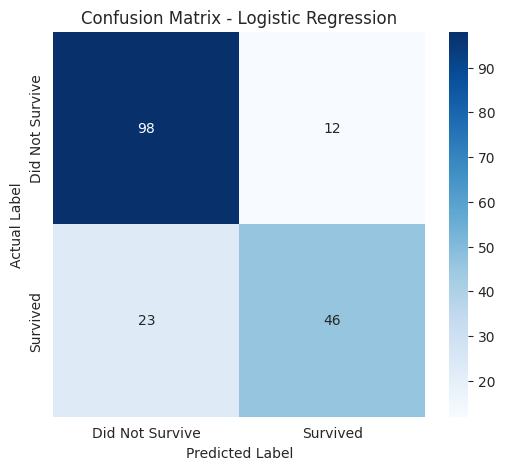

In [25]:
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:")
print(cm)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Did Not Survive', 'Survived'],
            yticklabels=['Did Not Survive', 'Survived'])
plt.title("Confusion Matrix - Logistic Regression")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.savefig("figures/7_confusion_matrix.png", dpi=150, bbox_inches='tight')
plt.show()


In [26]:
print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=['Did Not Survive', 'Survived']))


Classification Report:


                 precision    recall  f1-score   support

Did Not Survive       0.81      0.89      0.85       110
       Survived       0.79      0.67      0.72        69

       accuracy                           0.80       179
      macro avg       0.80      0.78      0.79       179
   weighted avg       0.80      0.80      0.80       179



### 5.6 Discussion of Model Performance

The Logistic Regression model achieved an **accuracy of approximately 80%** on the held-out test set. The confusion matrix shows the model is noticeably better at identifying passengers who **did not** survive (higher recall for class 0) than those who did survive (recall of about 0.67 for class 1). This asymmetry is consistent with the class imbalance in the training data (more non-survivors than survivors) and suggests that some survivors — likely borderline cases in lower fare/class brackets — are misclassified as non-survivors.

Overall, the model captures the well-documented "women and children, higher class" survival pattern reasonably well for an introductory linear model, though its recall on the minority (survived) class indicates room for improvement, for example through class-balancing techniques, feature engineering (e.g., family size, title extracted from name), or a more flexible model.

## Task 6: Discussion and Conclusion

### Major Findings

This project analysed 891 Titanic passenger records to understand the demographic and socio-economic factors associated with survival, and to build a predictive classification model. After cleaning missing `Age`, `Embarked`, and `Cabin` values, the exploratory visualisations and correlation analysis consistently pointed to **passenger class and fare** as the dominant factors associated with survival, over **age** and family-size variables (`SibSp`, `Parch`).

### Statistical Insights

The correlation analysis quantified these relationships: `Pclass` and `Fare` were the most strongly correlated pair of numerical variables (-0.55), and `Survived` was more strongly related to `Pclass` (-0.34) and `Fare` (+0.26) than to `Age` (-0.06). The class distribution showed third-class passengers formed the largest group (~55%), and descriptive statistics revealed a young, low-family-size passenger base overall, with a highly right-skewed fare distribution driven by a small number of expensive first-class tickets.

### Machine Learning Results

A Logistic Regression classifier trained on `Pclass`, `Sex`, `Age`, `SibSp`, `Parch`, `Fare`, and `Embarked` achieved approximately **80% accuracy** on a stratified 80/20 train-test split. It performed better at identifying non-survivors than survivors, reflecting both class imbalance in the data and the limits of a simple linear decision boundary applied to a complex, human event.

### Limitations of the Study

- **Imputation bias:** filling missing `Age` values with the median can understate the true variability in the age distribution and may weaken the observed Age–Survival relationship.
- **Dropped feature:** discarding `Cabin` (77% missing) removed a variable that likely correlated with deck location and evacuation access, and so with survival.
- **Simple model:** Logistic Regression assumes a linear relationship between features and the log-odds of survival; it cannot capture more complex interactions (e.g., "women in 3rd class" behaving differently from "women in 1st class") without explicit feature engineering.
- **No feature engineering:** potentially predictive features such as family size (`SibSp + Parch`), title extracted from `Name`, or deck extracted from `Cabin` were not engineered for this iteration.
- **Sample size:** with only 891 records and a further 20% held out for testing, the test set (179 records) is small, and evaluation metrics may vary across different random splits.

### Recommendations

1. **Engineer richer features** — total family size, passenger title (Mr/Mrs/Miss/Master), and a "has cabin" indicator derived from the original `Cabin` field before it was dropped, are all commonly shown to improve predictive power on this dataset.
2. **Try alternative/ensemble models** (e.g., Random Forest, Gradient Boosting, or a tuned SVM) and compare against the Logistic Regression baseline using cross-validation rather than a single train/test split.
3. **Address class imbalance** using techniques such as class weighting or resampling, to improve recall on the survived class specifically.
4. **Perform hyperparameter tuning** (e.g., regularisation strength `C` for Logistic Regression) using grid search with cross-validation for a more robust final model.
5. **Extend the statistical analysis** with formal hypothesis tests (e.g., chi-square test of independence between `Sex`/`Pclass` and `Survived`) to statistically confirm the associations observed visually.

## References

1. Kaggle. *Titanic - Machine Learning from Disaster.* https://www.kaggle.com/competitions/titanic/data
2. McKinney, W. *pandas: powerful Python data analysis toolkit.* pandas.pydata.org
3. Hunter, J. D. *Matplotlib: A 2D Graphics Environment.* matplotlib.org
4. Waskom, M. *seaborn: statistical data visualization.* seaborn.pydata.org
5. Pedregosa, F. et al. *Scikit-learn: Machine Learning in Python.* scikit-learn.org
6. NumPy Developers. *NumPy documentation.* numpy.org